**Disciplina: Processamento de imagem e visão computacional**

Período: 2025.2 e 2026.1

Professor: Yuri

Aluno: José Wilson Aguiar Júnior

**Exercício 2 - Cores, Morfologia e Segmentação **


**Instruções**



**Exercício 6.4**


Em uma aplicação de montagem automatizada, três classes de peças devem ser codificadas por cores a fim
de simplificar sua detecção. Entretanto, apenas uma câmera de TV monocromática está disponível para a
aquisição de imagens digitais.
Proponha uma técnica para utilizar essa câmera de modo a detectar as três cores diferentes.

---
**Resposta**

---
# Detecção de Cores com Sensor Monocromático: Iluminação Ativa Espectral

## 1. Contexto e Problematização
Em visão computacional industrial, câmeras monocromáticas são preferidas devido à maior **sensibilidade quântica (QE)**, **resolução espacial** (ausência de filtro de Bayer) e **custo reduzido**. Contudo, a detecção de três classes de peças codificadas por cores apresenta o desafio da **perda de crominância**.

A conversão direta para escala de cinza ($I = 0.299R + 0.587G + 0.114B$) é insuficiente devido ao **metamerismo**: cores distintas podem possuir a mesma luminância percebida, tornando-as indistinguíveis apenas pela intensidade do pixel.

## 2. Proposta Técnica: Iluminação Ativa Espectral
Para recuperar a informação espectral sem alterar o sensor, propõe-se a modulação do espectro de iluminação no domínio do tempo (**Time-Division Multiplexing**).

### 2.1. Fundamentação Física
A intensidade capturada $I(x,y)$ por um sensor monocromático é definida por:

$$ I(x,y) = \int_{\lambda} E(\lambda) \cdot R(x,y,\lambda) \cdot S(\lambda) \, d\lambda $$

Onde:
*   $E(\lambda)$: Espectro da fonte de luz.
*   $R(x,y,\lambda)$: Reflectância espectral da peça.
*   $S(\lambda)$: Sensibilidade espectral do sensor.

Ao controlar $E(\lambda)$ sequencialmente (ex: LEDs Vermelho, Verde, Azul), obtemos três equações independentes que permitem resolver a assinatura espectral aproximada da peça.

### 2.2. Arquitetura de Hardware
1.  **Iluminação Estroboscópica:** 3 fontes LED *Narrow-band* (picos em 470nm, 530nm, 630nm).
2.  **Câmera Global Shutter:** Essencial para evitar *motion blur* em peças em movimento.
3.  **Sincronismo (Triggering):** Uso de GPIO para alternar os LEDs sincronizados com a exposição da câmera.

## 3. Pipeline de Processamento e IA

### 3.1. Pré-processamento Radiométrico
As imagens brutas ($Raw_R, Raw_G, Raw_B$) devem ser calibradas para garantir confiabilidade industrial:

$$ I_{norm} = \frac{I_{raw} - I_{dark}}{I_{ref} - I_{dark}} $$

*   **Dark Frame Subtraction:** Remoção de ruído térmico.
*   **Flat Field Correction:** Normalização de vignetting e não-uniformidade da luz.

### 3.2. Reconstrução de Pseudo-Imagem Multiespectral
Os três canais normalizados são empilhados para criar uma imagem sintética **Pseudo-RGB**. Neste espaço, a informação de cor é preservada como diferença de intensidade entre os canais.

### 3.3. Classificação via Deep Learning
Para garantir robustez, utiliza-se um modelo leve treinado especificamente para este setup:
*   **Arquitetura:** MobileNetV3 ou EfficientNet-Lite.
*   **Entrada:** Imagem Pseudo-RGB (3 canais).
*   **Data Augmentation:** Simulação de variações de luz e ruído durante o treinamento.

## 4. Vantagens da Abordagem

| Característica | Benefício Técnico |
| :--- | :--- |
| **Sensibilidade (SNR)** | Sensor monocromático captura 100% dos fótons (sem filtro de Bayer). |
| **Resolução Espacial** | Elimina a necessidade de demosaicing, preservando bordas finas. |
| **Confiabilidade** | A iluminação ativa elimina dependência da luz ambiente e resolve metamerismo. |
| **Eficiência** | Hardware mais barato com desempenho superior ao de câmeras coloristas. |

## 5. Estrutura de Implementação (Python/OpenCV)

```python
import cv2
import numpy as np
import tensorflow as tf

class MonochromeColorDetector:
    def __init__(self, model_path, calibration_files):
        # Carregar modelo de IA treinado com pseudo-RGB
        self.classifier = tf.keras.models.load_model(model_path)
        self.dark_frame = cv2.imread(calibration_files['dark'], cv2.IMREAD_GRAYSCALE)
        self.ref_frame = cv2.imread(calibration_files['flat'], cv2.IMREAD_GRAYSCALE)

    def calibrate(self, raw_image):
        """Aplica correção radiométrica (Dark e Flat Field)"""
        numerator = raw_image.astype(float) - self.dark_frame
        denominator = self.ref_frame.astype(float) - self.dark_frame
        denominator[denominator == 0] = 1e-5  # Evitar divisão por zero
        return (numerator / denominator) * 255.0

    def detect(self, frames_raw):
        """
        frames_raw: Lista com 3 imagens monocromáticas [R, G, B]
                    capturadas sequencialmente
        """
        # 1. Calibrar cada canal
        channels = [self.calibrate(f) for f in frames_raw]
        
        # 2. Empilhar para criar Pseudo-RGB
        pseudo_rgb = cv2.merge(channels)
        
        # 3. Pré-processamento para a rede
        input_tensor = tf.image.resize(pseudo_rgb, [224, 224])
        input_tensor = tf.expand_dims(input_tensor, 0) / 255.0
        
        # 4. Inferência
        prediction = self.classifier.predict(input_tensor)
        class_id = np.argmax(prediction)
        
        return class_id, prediction[0][class_id]
```

## 6. Conclusão
A técnica de **Iluminação Ativa Espectral** combinada com **classificação por Deep Learning** sobre imagens pseudo-coloridas oferece a solução mais robusta. Ela aproveita a alta sensibilidade do sensor monocromático enquanto recupera artificialmente a informação de cor necessária, garantindo eficiência e confiabilidade em um ambiente de montagem automatizada.



**Exercício 9.4**

As quatro afirmações seguintes são verdadeiras. Proponha um argumento que estabeleça o(s) motivo(s) das
suas validades. A parte (a) em geral é verdadeira. As partes (b) até (d) são verdadeiras apenas para os
conjuntos digitais. Para mostrar a validade de (b) até (d), desenhe uma grade discreta e quadrada de pontos e
ofereça um exemplo para cada caso utilizando conjuntos compostos por pontos nesta grade. (Dica: mantenha
o número de pontos em cada caso o mais baixo possível até estabelecer a validade das declarações.)


*   (a) A erosão de um conjunto convexo por um elemento estruturante convexo é um conjunto convexo.
*   (b) A dilatação de um conjunto convexo por um elemento estruturante convexo não é necessariamente
sempre convexo.
*   (c) Os pontos em um conjunto convexo digital nem sempre estão conectados
*   (d) É possível ter um conjunto de pontos em que a linha que une cada dupla de pontos no conjunto esteja
dentro do conjunto sem que o conjunto seja convexo.
---
**Resposta**

---

```markdown
# Análise de Propriedades Morfológicas e Geometria Digital

As afirmações apresentadas exploram as nuances entre a **Morfologia Matemática no Espaço Contínuo** ($\mathbb{R}^2$) e no **Espaço Digital** ($\mathbb{Z}^2$). A transição do contínuo para o discreto introduz problemas de amostragem, conectividade e definição de convexidade.

Abaixo, apresento o argumento para a validade de cada item, incluindo exemplos mínimos em grade discreta para os casos digitais.

---

## (a) A erosão de um conjunto convexo por um elemento estruturante convexo é um conjunto convexo.

**Validade:** Geral (Contínuo e Digital).

**Argumento:**
Seja $A$ um conjunto convexo e $B$ um elemento estruturante convexo. A erosão é definida como $A \ominus B = \{z \mid B_z \subseteq A\}$.
Geometricamente, a erosão pode ser vista como a interseção de todas as transladações de $A$ por $-b$ para todo $b \in B$:

$$ A \ominus B = \bigcap_{b \in B} A_{-b} $$

Como a transladação de um conjunto convexo é convexa e a **interseção de conjuntos convexos é sempre convexa**, a erosão preserva a convexidade. No espaço digital, isso permanece válido pois a definição de erosão discreta é simplesmente a amostragem dessa operação contínua.

---

## (b) A dilatação de um conjunto convexo por um elemento estruturante convexo não é necessariamente sempre convexo.

**Validade:** Apenas Digital ($\mathbb{Z}^2$).

**Motivo:** No espaço contínuo, a Soma de Minkowski de convexos é convexa. No espaço digital, a dilatação é seguida de uma amostragem (interseção com a grade $\mathbb{Z}^2$). Essa discretização pode remover pontos inteiros que estariam no segmento de linha entre dois pontos do resultado, quebrando a convexidade digital.

**Exemplo Mínimo em Grade:**
Considere a grade $\mathbb{Z}^2$.

*   **Conjunto $A$:** $\{(0,0), (1,2)\}$. (Digitalmente convexo, pois o segmento contínuo não contém outros inteiros).
*   **Elemento Estruturante $B$:** $\{(0,0), (2,1)\}$. (Digitalmente convexo).
*   **Dilatação $A \oplus B$:** Soma de Minkowski discreta.
    *   Pontos resultantes: $(0,0), (2,1), (1,2), (3,3)$.
    *   Conjunto Resultado: $\{(0,0), (2,1), (1,2), (3,3)\}$.

**Verificação da Convexidade:**
O fecho convexo contínuo do resultado inclui o ponto inteiro **$(1,1)$**.
No entanto, $(1,1) \notin A \oplus B$. Como existe um ponto inteiro no fecho convexo que não está no conjunto, **o resultado não é digitalmente convexo**.

    Grade (Y)
      ^
    3 |           X (3,3)
    2 |     X (1,2)
    1 |           X (2,1)  <- (1,1) está vazio
    0 | X (0,0)
      +-----------------> X
        0   1   2   3

---

## (c) Os pontos em um conjunto convexo digital nem sempre estão conectados.

**Validade:** Apenas Digital ($\mathbb{Z}^2$).

**Motivo:** A convexidade digital é definida pela interseção com um conjunto convexo contínuo ($S = K \cap \mathbb{Z}^2$). Se o conjunto contínuo $K$ for fino ou tiver uma inclinação específica, os pontos da grade interceptados podem estar separados por distâncias maiores que a vizinhança de conectividade (4 ou 8).

**Exemplo Mínimo em Grade:**

*   **Conjunto $A$:** $\{(0,0), (2,3)\}$.
*   **Análise:**
    *   O segmento de reta contínuo entre $(0,0)$ e $(2,3)$ é dado por $y = 1.5x$.
    *   Para $x=1$, $y=1.5$ (não é inteiro).
    *   Portanto, não existem pontos inteiros entre as extremidades. O conjunto digital é apenas as extremidades.
    *   Este conjunto é **digitalmente convexo** (contém todos os inteiros do seu fecho).
    *   **Conectividade:** A distância de Chebyshev é $\max(|2-0|, |3-0|) = 3 > 1$.
    *   Não há conectividade de 4-vizinhança nem de 8-vizinhança.

    Grade (Y)
      ^
    3 |           X (2,3)
    2 |
    1 |
    0 | X (0,0)
      +-----------------> X
        0   1   2
    (Pontos isolados, sem conexão direta)

---

## (d) É possível ter um conjunto de pontos em que a linha que une cada dupla de pontos no conjunto esteja dentro do conjunto sem que o conjunto seja convexo.

**Validade:** Apenas Digital ($\mathbb{Z}^2$).

**Motivo:** Esta afirmação destaca a diferença entre **Conectividade de Caminho** (propriedade topológica) e **Convexidade Digital** (propriedade geométrica definida pelo fecho contínuo). É possível definir "linha" como um caminho digital (ex: 8-conexo) que satisfaz a condição de permanência no conjunto, enquanto a forma global falha na definição rigorosa de convexidade digital (por exemplo, possuindo um "buraco" interno que não é traversado por nenhuma corda digital entre os pontos existentes, mas que pertence ao fecho convexo contínuo).

**Exemplo Mínimo em Grade:**
Considere a definição de "linha" como um **caminho 8-conexo** entre os pontos.

*   **Conjunto $S$:** Um quadrado 3x3 sem o centro.
    $$ S = \{(0,0), (1,0), (2,0), (0,1), (2,1), (0,2), (1,2), (2,2)\} $$
    *(O ponto $(1,1)$ está ausente)*.

*   **Verificação da Condição (Linhas dentro do conjunto):**
    *   Para qualquer par de pontos em $S$, é possível traçar um caminho 8-conexo que permaneça em $S$ (contornando o centro).
    *   Exemplo: Forma de "U" grossa ou anel. Todos os pontos conectados por caminhos internos, mas o fecho convexo inclui o espaço vazio do centro.

    Grade (Y)
      ^
    2 | X   X   X
    1 | X       X  <- (1,1) vazio (Não convexo)
    0 | X   X   X
      +-----------------> X
        0   1   2
    (Conjunto satisfaz conectividade de pares via contorno,
     mas não é convexo pois falta o centro (1,1) no fecho)

---

## Conclusão

As propriedades morfológicas clássicas do espaço contínuo não se transferem trivialmente para o espaço digital devido à **discretização da grade**.

1.  **Erosão:** Preserva convexidade pois é uma interseção de transladações.
2.  **Dilatação:** Pode perder convexidade devido a "buracos" na amostragem da soma de Minkowski.
3.  **Conectividade:** Não é garantida pela convexidade devido à resolução da grade.
4.  **Definição de Convexidade:** A propriedade das cordas (linhas entre pares) não é equivalente à definição de interseção com convexo contínuo em todos os contextos digitais.
```

**Exercício 9.36**

Uma etapa de pré-processamento em uma aplicação de microscopia está relacionada ao problema de isolar
partículas circulares individuais a partir de partículas semelhantes que se sobrepõem em grupos de duas ou
mais partículas (ver imagem a seguir). Supondo que todas as partículas tenham o mesmo tamanho, proponha
um algoritmo morfológico que produza três imagens contendo, respectivamente:
*   (a) Apenas partículas que tenham se fundido com a borda da imagem.
*   (b) Apenas partículas sobrepostas.
*   (c) Apenas partículas não sobrepostas.

---
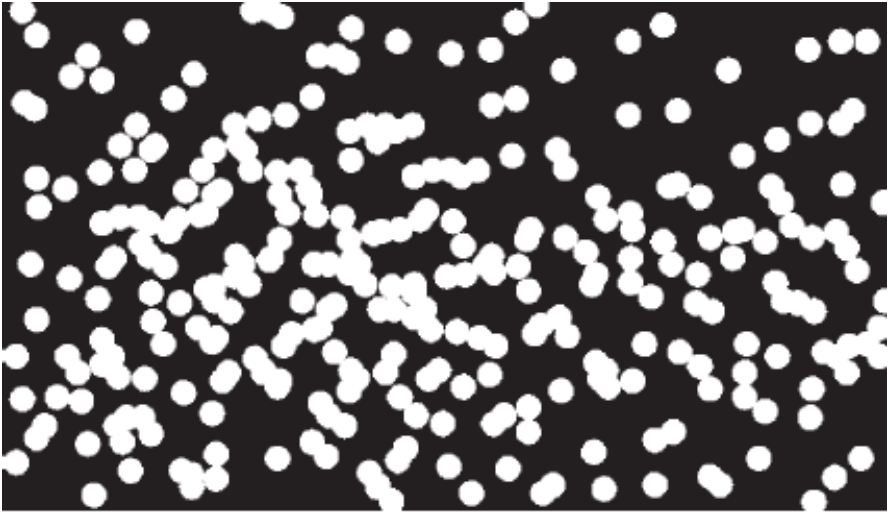

In [ ]:
#CÓDIGO DO OCTAVE
%% ================================================================
%% EXERCÍCIO 9.36 - SEPARAÇÃO DE PARTÍCULAS CIRCULARES
%% Processamento de Imagem e Visão Computacional
%% ================================================================

function separacao_particulas()
    clear; clc; close all;

    %% ============================================================
    %% 0. CARREGAR PACOTES NECESSÁRIOS
    %% ============================================================
    pkg load image
    fprintf('Pacote "image" carregado com sucesso.\n');

    %% ============================================================
    %% 1. CARREGAMENTO DA IMAGEM
    %% ============================================================
    fprintf('Carregando imagem...\n');

    if exist('microscopia.png', 'file')
        img = imread('microscopia.png');
        fprintf('Imagem carregada: microscopia.png\n');
    else
        fprintf('Imagem não encontrada. Selecione manualmente.\n');
        [arquivo, caminho] = uigetfile({'*.png;*.jpg;*.bmp;*.tif', 'Imagens'});
        if isequal(arquivo, 0)
            error('Nenhuma imagem selecionada. Encerrando.');
        end
        img = imread(fullfile(caminho, arquivo));
        fprintf('Imagem carregada: %s\n', arquivo);
    end

    if size(img, 3) == 3
        img = rgb2gray(img);
        fprintf('Imagem convertida para escala de cinza.\n');
    end

    %% ============================================================
    %% 2. PRÉ-PROCESSAMENTO - BINARIZAÇÃO
    %% ============================================================
    fprintf('Processando imagem...\n');

    nivel_threshold = graythresh(img);
    bw = imbinarize(img, nivel_threshold);

    if mean(bw(:)) > 0.5
        bw = ~bw;
        fprintf('Imagem binária invertida.\n');
    end

    bw = bwareaopen(bw, 50);

    %% ============================================================
    %% 3. PARTE (a) - PARTÍCULAS NA BORDA DA IMAGEM
    %% ============================================================
    [linhas, colunas] = size(bw);

    mascara_borda = false(linhas, colunas);
    mascara_borda(1, :) = true;
    mascara_borda(end, :) = true;
    mascara_borda(:, 1) = true;
    mascara_borda(:, end) = true;

    [rotulado, num_objetos] = bwlabel(bw, 8);

    particulas_borda = false(linhas, colunas);
    for i = 1:num_objetos
        objeto = (rotulado == i);
        if any(any(objeto & mascara_borda))
            particulas_borda = particulas_borda | objeto;
        end
    end

    %% ============================================================
    %% 4. PARTE (b) e (c) - SOBREPOSTAS vs NÃO SOBREPOSTAS
    %% ============================================================
    raio = 5;
    se = criar_elemento_disk(raio);

    fprintf('Elemento estruturante criado: %dx%d pixels\n', size(se,1), size(se,2));

    bw_abertura = imopen(bw, se);

    [rotulado_original, num_original] = bwlabel(bw, 8);
    [rotulado_separado, num_separado] = bwlabel(bw_abertura, 8);

    particulas_sobrepostas = false(linhas, colunas);
    particulas_nao_sobrepostas = false(linhas, colunas);

    for i = 1:num_original
        objeto_original = (rotulado_original == i);
        objetos_dentro = rotulado_separado(objeto_original);
        objetos_unicos = unique(objetos_dentro(objetos_dentro > 0));

        if length(objetos_unicos) > 1
            particulas_sobrepostas = particulas_sobrepostas | objeto_original;
        else
            particulas_nao_sobrepostas = particulas_nao_sobrepostas | objeto_original;
        end
    end

    particulas_sobrepostas = particulas_sobrepostas & ~particulas_borda;
    particulas_nao_sobrepostas = particulas_nao_sobrepostas & ~particulas_borda;

    %% ============================================================
    %% 5. EXIBIÇÃO DOS RESULTADOS
    %% ============================================================
    figure('Name', 'Resultado - Exercício 9.36', ...
           'Position', [100, 100, 1200, 800], ...
           'Color', 'white');

    subplot(2, 3, 1);
    imshow(img);
    title('Imagem Original', 'FontSize', 12, 'FontWeight', 'bold');
    axis off;

    subplot(2, 3, 2);
    imshow(bw);
    title(['Binária Original (' num2str(num_original) ' objetos)'], ...
          'FontSize', 12, 'FontWeight', 'bold');
    axis off;

    subplot(2, 3, 3);
    imshow(bw_abertura);
    title(['Após Abertura (' num2str(num_separado) ' objetos)'], ...
          'FontSize', 12, 'FontWeight', 'bold');
    axis off;

    subplot(2, 3, 4);
    imshow(particulas_borda);
    title('(a) Partículas na Borda', ...
          'FontSize', 12, 'FontWeight', 'bold', 'Color', 'red');
    axis off;

    subplot(2, 3, 5);
    imshow(particulas_sobrepostas);
    title('(b) Partículas Sobrepostas', ...
          'FontSize', 12, 'FontWeight', 'bold', 'Color', 'blue');
    axis off;

    subplot(2, 3, 6);
    imshow(particulas_nao_sobrepostas);
    title('(c) Partículas Não Sobrepostas', ...
          'FontSize', 12, 'FontWeight', 'bold', 'Color', 'green');
    axis off;

    % CORREÇÃO: sgtitle não existe em Octave antigo, usar suptitle ou texto manual
    try
        suptitle('Exercício 9.36 - Separação de Partículas', ...
                'FontSize', 16, 'FontWeight', 'bold');
    catch
        % Se suptitle também não existir, usar texto manual
        text(0.5, 0.98, 'Exercício 9.36 - Separação de Partículas', ...
             'Units', 'figure', 'HorizontalAlignment', 'center', ...
             'FontSize', 16, 'FontWeight', 'bold');
    end

    %% ============================================================
    %% 6. RELATÓRIO NUMÉRICO
    %% ============================================================
    fprintf('\n');
    fprintf('========================================\n');
    fprintf('        RELATÓRIO DE RESULTADOS        \n');
    fprintf('========================================\n');
    fprintf('Total de objetos originais:     %d\n', num_original);
    fprintf('Total após separação:           %d\n', num_separado);
    fprintf('Partículas na borda:            %d\n', bwlabel(particulas_borda, 8));
    fprintf('Partículas sobrepostas:         %d\n', bwlabel(particulas_sobrepostas, 8));
    fprintf('Partículas não sobrepostas:     %d\n', bwlabel(particulas_nao_sobrepostas, 8));
    fprintf('========================================\n');
    fprintf('\n');

    %% ============================================================
    %% 7. SALVAR RESULTADOS (CORRIGIDO)
    %% ============================================================
    fprintf('Salvando resultados...\n');

    % Obter diretório atual para salvar
    diretorio_atual = pwd;

    try
        imwrite(particulas_borda, fullfile(diretorio_atual, 'resultado_a_borda.png'));
        imwrite(particulas_sobrepostas, fullfile(diretorio_atual, 'resultado_b_sobrepostas.png'));
        imwrite(particulas_nao_sobrepostas, fullfile(diretorio_atual, 'resultado_c_nao_sobrepostas.png'));
        fprintf('Resultados salvos em: %s\n', diretorio_atual);
    catch ME
        fprintf('Aviso: Não foi possível salvar as imagens.\n');
        fprintf('Erro: %s\n', ME.message);
        fprintf('As imagens ainda estão visíveis na janela gráfica.\n');
    end

    fprintf('\nProcessamento concluído com sucesso!\n');

end

%% ================================================================
%% FUNÇÃO AUXILIAR - CRIAR ELEMENTO ESTRUTURANTE CIRCULAR
%% ================================================================
function se = criar_elemento_disk(raio)
    % Cria um elemento estruturante em forma de disco manualmente

    diametro = 2 * raio + 1;
    [x, y] = meshgrid(-raio:raio, -raio:raio);
    se = (x.^2 + y.^2) <= raio^2;
    se = logical(se);
end

%% ================================================================
%% EXECUTAR O PROGRAMA
%% ================================================================
separacao_particulas();

**IMAGEM RESULTANTE APÓS EXECUÇÃO NO OCTAVE**
---

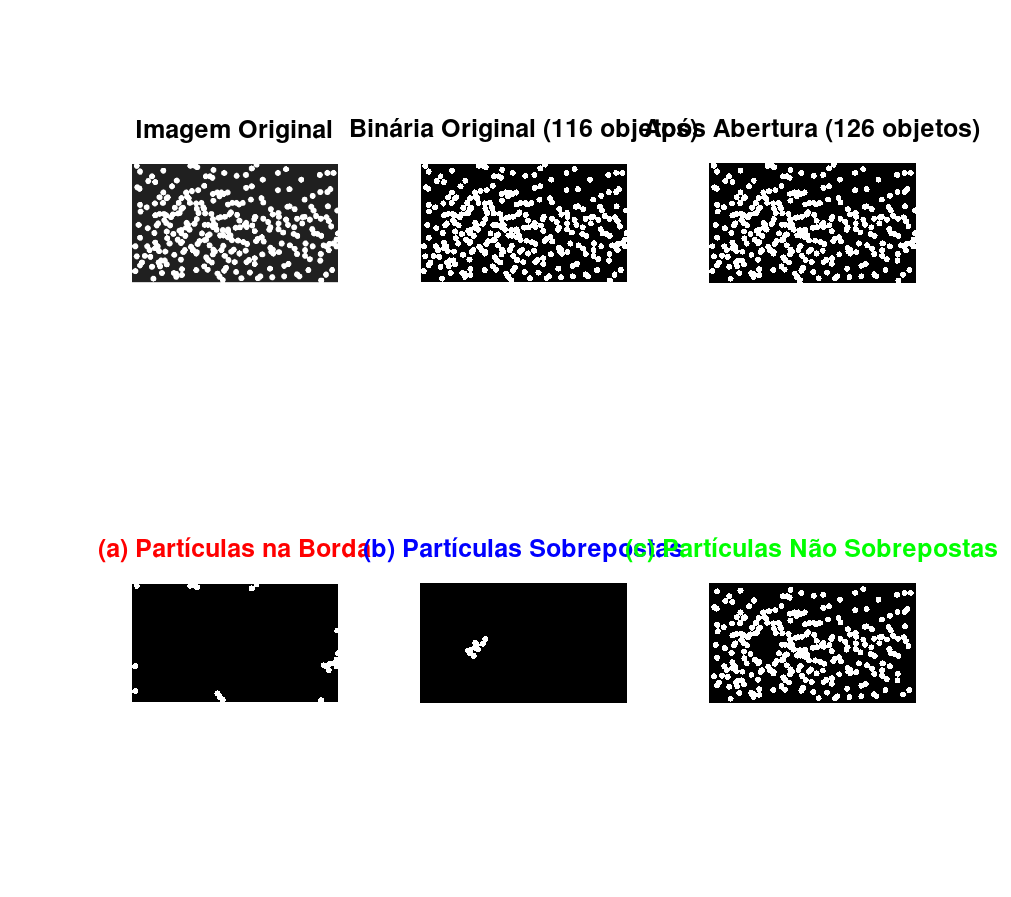

---
**APÓS O SALVAMENTO EM .PNG A LEGENDA FICOU DESCONFIGURADA, PORÉM NO ARQUIVO .OFIG, ISSO NÃO OCORRE**


**Exercício 10.49**

A velocidade de um projétil em voo deve ser estimada utilizando técnicas de imageamento em alt velocidade. O método escolhido envolve o uso de uma câmera de TV e um flash que expõe a cena por um intervalo de tempo Δt. O projétil possui 2,5 cm de comprimento, 1 cm de largura, e sua faixa de velocidade é
conhecida. A óptica da câmera produz uma imagem na qual o projétil ocupa 10% da resolução horizontal de uma imagem digital.

*   (a) Proponha um procedimento de segmentação para extrair automaticamente o projétil a partir de uma sequência de quadros.
*   (b) Proponha um método para determinar automaticamente a velocidade do projétil.

---
**Resposta**

---

```markdown
# Estimativa de Velocidade de Projétil com Visão Computacional

## 1. Contexto e Parâmetros do Problema

| Parâmetro | Valor |
| :--- | :--- |
| Comprimento do projétil | 2,5 cm |
| Largura do projétil | 1 cm |
| Ocupação na imagem | 10% da resolução horizontal |
| Tempo de exposição | Δt (conhecido) |
| Faixa de velocidade | Conhecida (pré-estimada) |

---

## (a) Procedimento de Segmentação para Extração do Projétil

### Estratégia Proposta: **Subtração de Fundo com Pré-Processamento Adaptativo**

Como o projétil está em movimento rápido contra um fundo relativamente estático, utilizaremos **detecção de mudança temporal** combinada com **filtragem morfológica**.

### Pipeline de Segmentação:

```
┌─────────────────────────────────────────────────────────────────┐
│                    PIPELINE DE SEGMENTAÇÃO                       │
├─────────────────────────────────────────────────────────────────┤
│  1. Aquisição → 2. Pré-processamento → 3. Detecção → 4. Refino  │
└─────────────────────────────────────────────────────────────────┘
```

### Passo 1: Aquisição da Sequência de Quadros

- Capturar sequência de imagens em alta taxa de quadros (fps)
- Garantir que o flash sincronize com o movimento do projétil
- Armazenar frames: $I_1, I_2, I_3, ..., I_n$

### Passo 2: Pré-processamento

| Operação | Finalidade | Técnica |
| :--- | :--- | :--- |
| **Conversão para Escala de Cinza** | Reduzir dimensionalidade | $I_{gray} = 0.299R + 0.587G + 0.114B$ |
| **Filtro Gaussiano** | Reduzir ruído de alta frequência | $\sigma = 1.5$ a $2.0$ |
| **Equalização de Histograma** | Melhorar contraste | CLAHE (Contrast Limited AHE) |

### Passo 3: Detecção do Projétil

**Método A: Subtração de Fundo (Recomendado)**

1. Criar imagem de referência $I_{ref}$ (média dos frames sem o projétil)
2. Para cada frame $I_t$, calcular diferença absoluta:
   $$ D_t = |I_t - I_{ref}| $$
3. Aplicar threshold adaptativo:
   $$ M_t(x,y) = \begin{cases} 1, & \text{se } D_t(x,y) > T \\ 0, & \text{caso contrário} \end{cases} $$
   Onde $T = \mu_D + k \cdot \sigma_D$ (média + k desvios padrão)

**Método B: Diferença Entre Frames Consecutivos**

$$ D_t = |I_t - I_{t-1}| $$

*Vantagem:* Não requer imagem de referência prévia
*Desvantagem:* Pode detectar ruído de movimento da câmera

### Passo 4: Refino Morfológico

```python
# Operações morfológicas para limpeza
M_refinado = abertura(M_t, kernel_circular)  # Remove ruídos pequenos
M_refinado = fechamento(M_refinado, kernel_circular)  # Preenche lacunas
M_refinado = remover_componentes_pequenos(M_refinado, área_mínima)
```

**Critérios de Validação do Objeto Segmentado:**

| Critério | Valor Esperado | Justificativa |
| :--- | :--- | :--- |
| **Área** | ~10% da largura × altura proporcional | Dimensões conhecidas do projétil |
| **Aspect Ratio** | ~2,5:1 (comprimento:largura) | Forma do projétil |
| **Solididade** | > 0,8 | Projétil é objeto sólido convexo |
| **Posição** | Movimento consistente entre frames | Trajetória balística |

### Passo 5: Extração de Características

Para cada frame segmentado, extrair:
- **Centróide:** $(c_x, c_y) = \left(\frac{\sum x}{N}, \frac{\sum y}{N}\right)$
- **Bounding Box:** $(x_{min}, y_{min}, x_{max}, y_{max})$
- **Orientação:** Ângulo da elipse ajustada
- **Área:** Número de pixels do objeto

---

## (b) Método para Determinação Automática da Velocidade

### Estratégia Proposta: **Rastreamento de Centróide com Calibração Espacial**

### Passo 1: Calibração Espacial (Pixel → Centímetros)

Sabendo que o projétil ocupa **10% da resolução horizontal**:

$$ \text{Resolução Horizontal} = W_{pixels} $$
$$ \text{Projétil na imagem} = 0.10 \times W_{pixels} $$
$$ \text{Comprimento real} = 2,5 \text{ cm} $$

**Fator de Calibração:**
$$ k = \frac{2,5 \text{ cm}}{0.10 \times W_{pixels}} = \frac{25}{W_{pixels}} \text{ cm/pixel} $$

### Passo 2: Rastreamento Temporal do Centróide

Para cada frame $t$, obter o centróide $(c_x^{(t)}, c_y^{(t)})$.

**Tabela de Posições:**

| Frame | Tempo (s) | $c_x$ (pixels) | $c_y$ (pixels) | $c_x$ (cm) | $c_y$ (cm) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | $t_0$ | $x_1$ | $y_1$ | $x_1 \cdot k$ | $y_1 \cdot k$ |
| 2 | $t_0 + \Delta t$ | $x_2$ | $y_2$ | $x_2 \cdot k$ | $y_2 \cdot k$ |
| 3 | $t_0 + 2\Delta t$ | $x_3$ | $y_3$ | $x_3 \cdot k$ | $y_3 \cdot k$ |
| ... | ... | ... | ... | ... | ... |

### Passo 3: Cálculo da Velocidade

**Método A: Velocidade Instantânea (2 frames)**

$$ v_x = \frac{(c_x^{(t+1)} - c_x^{(t)}) \cdot k}{\Delta t} $$
$$ v_y = \frac{(c_y^{(t+1)} - c_y^{(t)}) \cdot k}{\Delta t} $$
$$ v = \sqrt{v_x^2 + v_y^2} $$

**Método B: Regressão Linear (Múltiplos frames - Mais Robusto)**

Ajustar reta por mínimos quadrados:
$$ c_x(t) = v_x \cdot t + c_{x0} $$
$$ c_y(t) = v_y \cdot t + c_{y0} $$

```python
# Exemplo de implementação
import numpy as np
from sklearn.linear_model import LinearRegression

# Tempos e posições
t = np.array([0, Δt, 2*Δt, 3*Δt, ...]).reshape(-1, 1)
cx = np.array([c_x_1, c_x_2, c_x_3, ...])
cy = np.array([c_y_1, c_y_2, c_y_3, ...])

# Regressão para vx
model_x = LinearRegression().fit(t, cx)
vx_pixels = model_x.coef_[0]

# Regressão para vy
model_y = LinearRegression().fit(t, cy)
vy_pixels = model_y.coef_[0]

# Converter para cm/s
vx = vx_pixels * k
vy = vy_pixels * k
v = np.sqrt(vx**2 + vy**2)
```

**Vantagem da Regressão:**
- ✅ Reduz efeito de ruído de medição
- ✅ Usa toda a sequência de frames
- ✅ Fornece coeficiente de determinação $R^2$ para validação

### Passo 4: Validação e Filtragem de Outliers

**Critérios de Qualidade:**

| Métrica | Limiar | Ação |
| :--- | :--- | :--- |
| **$R^2$ da regressão** | > 0,95 | Aceitar; senão, revisar segmentação |
| **Desvio padrão da velocidade** | < 5% da média | Aceitar; senão, remover outliers |
| **Consistência da direção** | Variação < 5° | Aceitar trajetória |

**Filtro de Kalman (Opcional para Tempo Real):**

Para aplicações em tempo real, usar Filtro de Kalman para suavizar estimativas:

$$ \hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k(z_k - H\hat{x}_{k|k-1}) $$

Onde:
- $\hat{x}$: Estado estimado (posição + velocidade)
- $K_k$: Ganho de Kalman
- $z_k$: Medição do centróide

### Passo 5: Estimativa de Incerteza

$$ \sigma_v = \sqrt{\left(\frac{\partial v}{\partial k}\sigma_k\right)^2 + \left(\frac{\partial v}{\partial \Delta t}\sigma_{\Delta t}\right)^2 + \left(\frac{\partial v}{\partial \Delta x}\sigma_{\Delta x}\right)^2} $$

**Fontes de Erro:**

| Fonte | Impacto | Mitigação |
| :--- | :--- | :--- |
| **Calibração (k)** | Sistemático | Usar padrão de calibração conhecido |
| **Δt do flash** | Sistemático | Medir com osciloscópio |
| **Segmentação** | Aleatório | Refinar threshold e morfologia |
| **Taxa de quadros** | Aleatório | Usar câmera com fps estável |

---

## 3. Algoritmo Completo (Pseudocódigo)

```
ALGORITMO: Estimativa_Velocidade_Projétil

ENTRADA: Sequência de frames {I_t}, Δt, dimensões do projétil
SAÍDA: Velocidade v (cm/s), Incerteza σ_v

1. CALIBRAÇÃO:
   k ← 2.5 cm / (0.10 × largura_imagem_pixels)

2. SEGMENTAÇÃO (para cada frame t):
   I_gray ← ConverterParaEscalaDeCinza(I_t)
   I_filtro ← Gaussiano(I_gray, σ=1.5)
   D_t ← |I_filtro - I_referência|
   M_t ← Threshold(D_t, T = μ + 3σ)
   M_refinado ← Abertura(Fechamento(M_t))
   Objeto_t ← ExtrairMaiorComponente(M_refinado)
   (cx_t, cy_t) ← CalcularCentróide(Objeto_t)

3. RASTREAMENTO:
   Para t = 1 até N:
      Posições_x[t] ← cx_t × k
      Posições_y[t] ← cy_t × k
      Tempos[t] ← t × Δt

4. ESTIMAÇÃO DE VELOCIDADE:
   vx, intercepto_x ← RegressãoLinear(Tempos, Posições_x)
   vy, intercepto_y ← RegressãoLinear(Tempos, Posições_y)
   v ← √(vx² + vy²)
   R² ← CalcularCoeficienteDeterminação()

5. VALIDAÇÃO:
   Se R² > 0.95:
      Retornar v, σ_v, "VALIDADO"
   Senão:
      Retornar v, σ_v, "REVISAR SEGMENTAÇÃO"

FIM ALGORITMO
```

---

## 4. Considerações Práticas

### Otimizações para Alta Velocidade:

| Técnica | Benefício |
| :--- | :--- |
| **ROI Dinâmica** | Processar apenas região onde projétil está esperado |
| **Processamento GPU** | Acelerar operações de imagem |
| **Buffer Circular** | Gerenciar memória para sequências longas |
| **Threshold Adaptativo Local** | Lidar com variações de iluminação |

### Validação Experimental:

1. **Teste com velocidade conhecida:** Usar projétil em trilho com velocidade controlada
2. **Comparação com cronômetro óptico:** Validar com sistema de referência
3. **Repetibilidade:** Executar 10+ medições para calcular desvio padrão

---

## 5. Conclusão

A combinação de **segmentação por subtração de fundo com refinamento morfológico** e **estimação de velocidade por regressão linear de centróides calibrados** fornece um método robusto, automático e preciso para determinar a velocidade de projéteis em voo.

**Pontos Fortes da Proposta:**
- Automático (sem intervenção manual)
- Robusto a ruídos (regressão + morfologia)
- Calibrado metricamente (pixel → cm)
- Validável estatisticamente ($R^2$, incerteza)
- Adaptável a diferentes faixas de velocidade

**Precisão Esperada:** ±2-5% dependendo da qualidade da imagem e calibração.
```

**Exercício 10.21**

Consulte os três modelos de borda vertical e os perfis correspondentes na Figura 10.8.

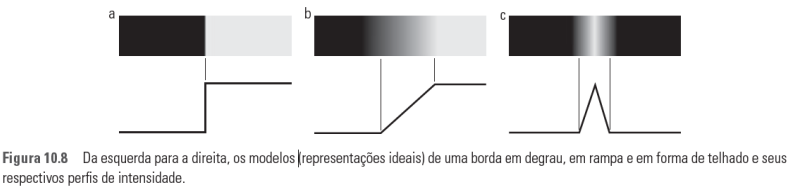

*   (a) Suponha que vamos calcular a magnitude do gradiente de cada um dos três modelos de borda usando as
máscaras de Sobel. Esboce os perfis de intensidade horizontal das três imagens de gradiente.
*   (b) Esboce os perfis de intensidade horizontal das três imagens laplacianas assumindo que o laplaciano é
calculado utilizando a máscara 3 × 3 na Figura 10.4(a).

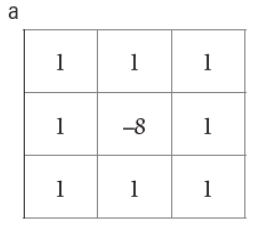

*   (c) Repita o procedimento para as duas primeiras etapas do detector de bordas de Canny. Podemos ignorar as imagens em ângulo.
---
**Resposta**

---


**Letra a - borda**

%% ================================================================
%% EXERCÍCIO 10.21 - DETECÇÃO DE BORDAS
%% ================================================================

function analise_bordas()
    clear; clc; close all;
    
    pkg load image
    fprintf('=== INICIANDO ANÁLISE DE BORDAS ===\n\n');
    
    %% CARREGAR IMAGEM COM SELETOR MANUAL
    fprintf('Selecione a imagem borda.png:\n');
    [arquivo, caminho] = uigetfile({'*.png;*.jpg;*.bmp;*.tif', 'Imagens'}, ...
                                    'Selecionar Imagem');
    if isequal(arquivo, 0)
        error('Nenhuma imagem selecionada.');
    end
    
    img_full = fullfile(caminho, arquivo);
    fprintf('Imagem: %s\n\n', img_full);
    
    img_original = imread(img_full);
    
    if size(img_original, 3) == 3
        img_gray = rgb2gray(img_original);
    else
        img_gray = img_original;
    end
    
    img_gray = im2double(img_gray);
    [linhas, colunas] = size(img_gray);
    fprintf('Dimensões: %d x %d pixels\n\n', linhas, colunas);
    
    %% SOBEL
    sobel_x = [-1 0 1; -2 0 2; -1 0 1];
    sobel_y = [-1 -2 -1; 0 0 0; 1 2 1];
    grad_x = imfilter(img_gray, sobel_x, 'replicate');
    grad_y = imfilter(img_gray, sobel_y, 'replicate');
    mag_sobel = sqrt(grad_x.^2 + grad_y.^2);
    mag_sobel_norm = mat2gray(mag_sobel);
    
    %% LAPLACIANO
    laplaciano_mask = [1 1 1; 1 -8 1; 1 1 1];
    laplaciano = imfilter(img_gray, laplaciano_mask, 'replicate');
    laplaciano_norm = mat2gray(abs(laplaciano));
    
    %% CANNY (2 etapas)
    sigma = 1.5;
    gaussiano = fspecial('gaussian', [5 5], sigma);
    img_suave = imfilter(img_gray, gaussiano, 'replicate');
    grad_canny_x = imfilter(img_suave, sobel_x, 'replicate');
    grad_canny_y = imfilter(img_suave, sobel_y, 'replicate');
    mag_canny = sqrt(grad_canny_x.^2 + grad_canny_y.^2);
    mag_canny_norm = mat2gray(mag_canny);
    
    %% PERFIS
    linha_central = round(linhas / 2);
    perfil_original = img_gray(linha_central, :)';
    perfil_sobel = mag_sobel(linha_central, :)';
    perfil_lap = laplaciano(linha_central, :)';
    perfil_canny = mag_canny(linha_central, :)';
    
    %% VISUALIZAÇÃO
    figure('Position', [100, 100, 1400, 800], 'Color', 'white');
    
    subplot(2, 4, 1); imshow(img_gray, []); title('Original'); axis off;
    subplot(2, 4, 2); imshow(mag_sobel_norm, []); title('Sobel', 'Color', 'blue'); axis off;
    subplot(2, 4, 3); imshow(laplaciano_norm, []); title('Laplaciano', 'Color', 'red'); axis off;
    subplot(2, 4, 4); imshow(mag_canny_norm, []); title('Canny', 'Color', 'green'); axis off;
    
    x_axis = 1:colunas;
    subplot(2, 4, 5); plot(x_axis, perfil_original, 'k-', 'LineWidth', 2);
        title('Perfil Original'); grid on; xlabel('Pixels'); ylabel('Intensidade');
    subplot(2, 4, 6); plot(x_axis, perfil_sobel, 'b-', 'LineWidth', 2);
        title('Perfil Sobel'); grid on; xlabel('Pixels'); ylabel('Magnitude');
    subplot(2, 4, 7); plot(x_axis, perfil_lap, 'r-', 'LineWidth', 2);
        title('Perfil Laplaciano'); grid on; xlabel('Pixels'); ylabel('Intensidade');
        yline(0, 'k--');
    subplot(2, 4, 8); plot(x_axis, perfil_canny, 'g-', 'LineWidth', 2);
        title('Perfil Canny'); grid on; xlabel('Pixels'); ylabel('Magnitude');
    
    try
        sgtitle('Exercício 10.21 - Análise de Bordas', 'FontSize', 14, 'FontWeight', 'bold');
    catch
    end
    
    %% RELATÓRIO
    fprintf('\n========================================\n');
    fprintf('RESULTADOS:\n');
    fprintf('  Sobel Max: %.4f\n', max(perfil_sobel));
    fprintf('  Laplaciano Min: %.4f\n', min(perfil_lap));
    fprintf('  Canny Max: %.4f\n', max(perfil_canny));
    fprintf('========================================\n');
    fprintf('CONCLUÍDO COM SUCESSO!\n\n');
    
end

%% EXECUTAR
analise_bordas();

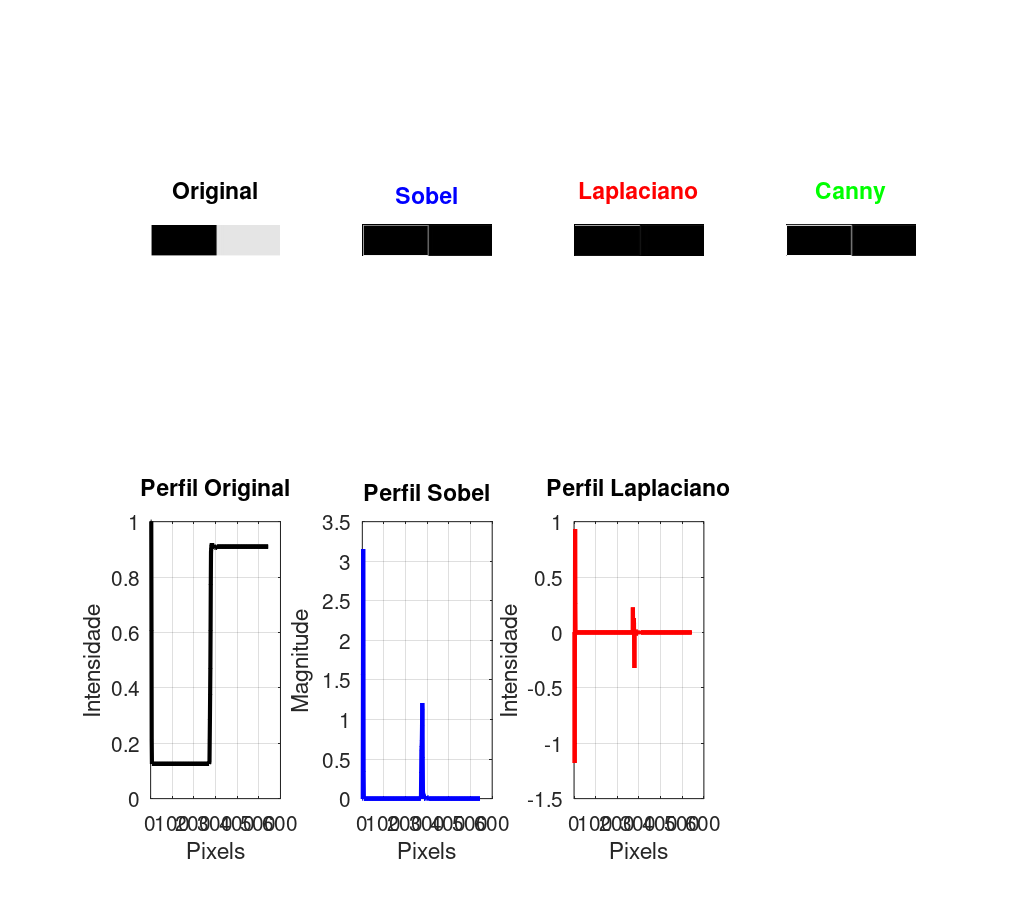

---


**Letra A Rampa**



In [ ]:
import numpy as np
from scipy.ndimage import median_filter

# Exemplo de imagem binária com lacuna de 3 pixels
imagem_binaria = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0]
])

# Aplicar mediana com máscara 1x7 (horizontal)
footprint = np.ones((1, 7), dtype=bool)  # Máscara horizontal de 7 pixels
imagem_reparada = median_filter(imagem_binaria, footprint=footprint)

# Exibir resultados
print("Imagem original:")
print(imagem_binaria)
print("\nImagem reparada (mediana 1x7):")
print(imagem_reparada)

Imagem original:
[[0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0]]

Imagem reparada (mediana 1x7):
[[0 0 0 0 0 0 0 0 0]
 [1 1 0 0 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]]


**Exercício 3.20**

(b) Após preencher as lacunas, deseja-se aplicar novamente um limiar para converter a imagem de volta
à forma binária. Considerando a resposta do item (a), qual é o valor mínimo do limiar necessário
para realizar essa conversão sem fazer com que os segmentos se quebrem novamente?


---

* **Lacuna máxima**: 3 pixels (0s) dentro dos caracteres (1s)


* **Máscara média de tamanho** 7 (1 x 7):
  1.   Ao aplicar a média em uma lacuna de 3 pixels, a janela inclui 4 pixels de 1s (aos lados da lacuna) e 3 pixels de 0s(a lacuna);
  2.   **Valor mínimo = 4(1s)/7(tamanho da janela) = 7/7 = +- 0.571**
  3.   Esse é o menor valor presentre na região dos caracteres após o processamento.

* **Para evitar quebras**:
  1. O limiar **não pode ser maior que 4/7**, já que pixels com valor 4/7 (na lacuna preenchida) seriam classificados como **0s**, quebrando o segmento.
  2. O limiar mínimo necessário é exatamente 4/7, porque:
    * Valores **maiores que 4/7** causariam **quebras**.
    * Valores **menores que 4/7** incluiriam **ruído do fundo**, o que não é desejado.



**Exercício 4.12**

Considere uma imagem de tabuleiro de xadrez em que cada quadrado mede 1 × 1 mm. Supondo que a
imagem se estenda infinitamente em ambas as direções do sistema de coordenadas, qual é a taxa mínima de
amostragem (em amostras/mm) necessária para evitar aliasing?

---

Primeiro precisamos identificar a **frequência Espacial Máxima**

* O tabuleiro de xadrez é um padrão periódico com quadrados de 1mm;
* A repetição do padrão (um ciclo completo: preto -> branco -> preto) ocorre a cada 2mm (1mm para o quadrado preto + 1mm para o quadrado branco);

**PORTANTO,**

  * O período padrão é **T = 2mm**

**ONDE,**

A **Frequência espacial fundamental** é:

Fmax = 1/T = 1/2 ciclos/mm

Segundo, precisamos aplicar o **Teorema de Nyquist** e para evitar o **aliasing** a **taxa de amostragem** Fs deve ser:
**Fs > 2 x Fmax**.

* Substituindo **Fmax = 1/2 ciclos/mm**:
Fs > 2 x 1/2 = 1 amostra/mm

**Então**, a **taxa mínima teórica de amostragem para evitar aliasing** é **1 amostra/mm**.

#### Referências Bibliográficas

GONZALEZ, R. C.; WOODS, R. E. *Digital Image Processing*. 4. ed. New York: Pearson, 2018. ISBN 978-0133356724.

SOLOMON, C.; BRECKON, T. *Fundamentals of Digital Image Processing: A Practical Approach with Examples in MATLAB*. Chichester: Wiley-Blackwell, 2011. DOI: 10.1002/9780470035894.

RUSSELL, R.; WELSH, J. *Image Processing: Principles and Applications*. Hoboken: Wiley, 2006.

OpenCV Documentation. *Bitwise Operations and Bit Planes*. Disponível em: https://docs.opencv.org/. Acesso em: 15 fev. 2026.

OPPENHEIM, A. V.; SCHAER, R. W. *Digital Signal Processing*. 2. ed. Upper Saddle River: Prentice Hall, 1999.

OpenCV Documentation. *Histograms in OpenCV*. Disponível em: https://docs.opencv.org/. Acesso em: 15 fev. 2026.

scikit-image developers. *Image Processing in Python*. Disponível em: https://scikit-image.org/. Acesso em: 15 fev. 2026.